In [1]:
# read the data
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd
import matplotlib

import mne


raw_file = r"D:\Data_at_IITJ\sub007\EEG\sub007_exp2.vhdr"
raw = mne.io.read_raw_brainvision(raw_file, preload=False)

Extracting parameters from D:\Data_at_IITJ\sub007\EEG\sub007_exp2.vhdr...
Setting channel info structure...


Using matplotlib as 2D backend.


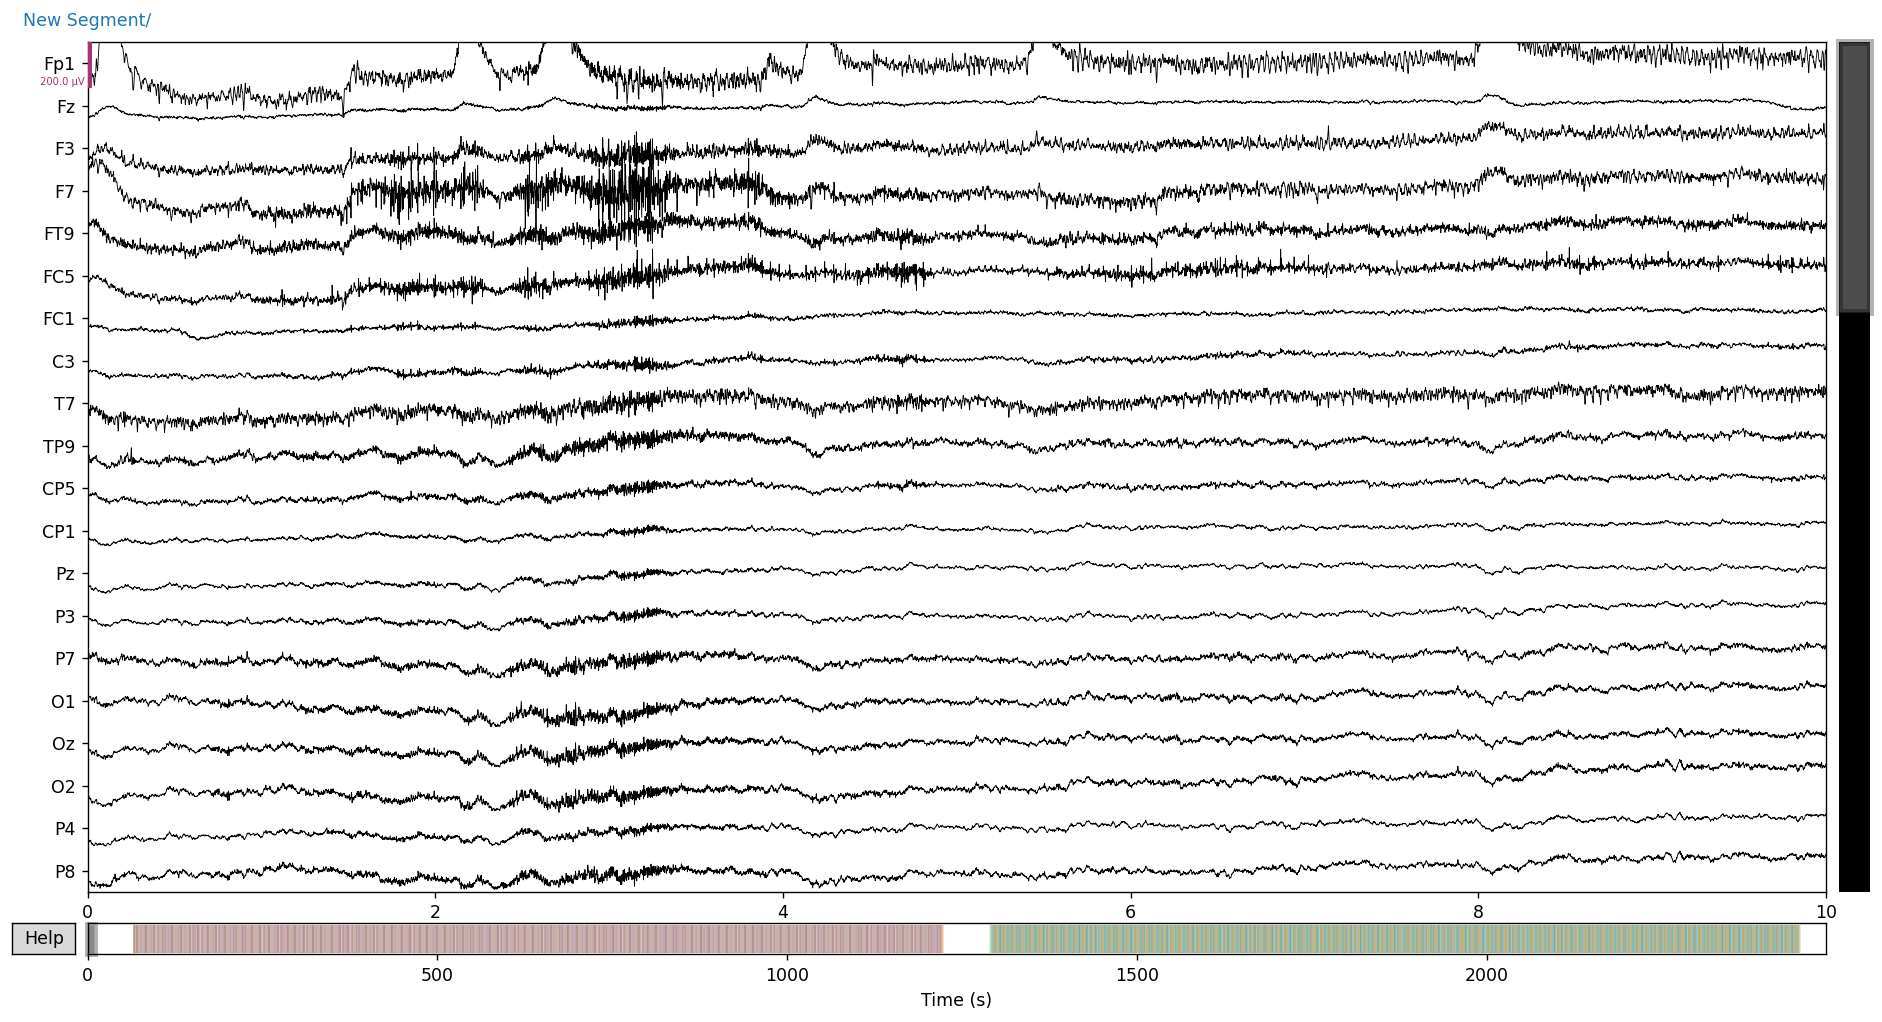

In [2]:
 # it is useful to scroll eeg data 
%matplotlib qt
raw.plot(scalings=dict(eeg=1e-4),clipping='transparent')

In [3]:
#import the channel loaction 
"""builtin_montages = mne.channels.get_builtin_montages(descriptions=True)
for montage_name, montage_description in builtin_montages:
    print(f"{montage_name}: {montage_description}") """
raw.set_montage("easycap-M1")

Measurement date,"June 02, 2024 13:12:19 GMT"
Experimenter,Unknown
Participant,Unknown
Digitized points,66 points
Good channels,63 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,1000.00 Hz
Highpass,0.00 Hz
Lowpass,280.00 Hz


Approximating Fpz location by mirroring Oz along the X and Y axes.


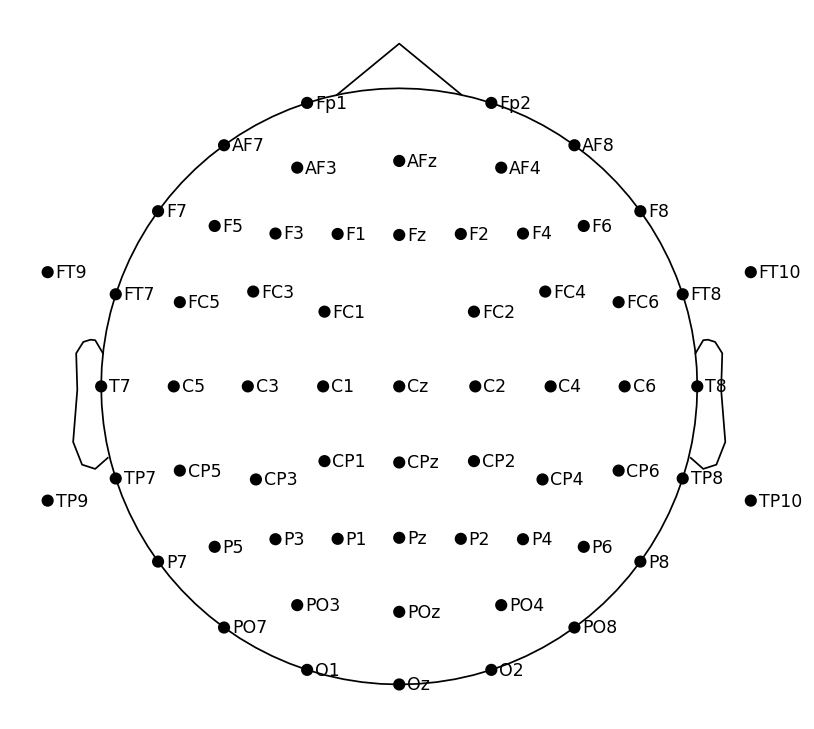

In [4]:

raw.plot_sensors(show_names=True, sphere="eeglab")

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


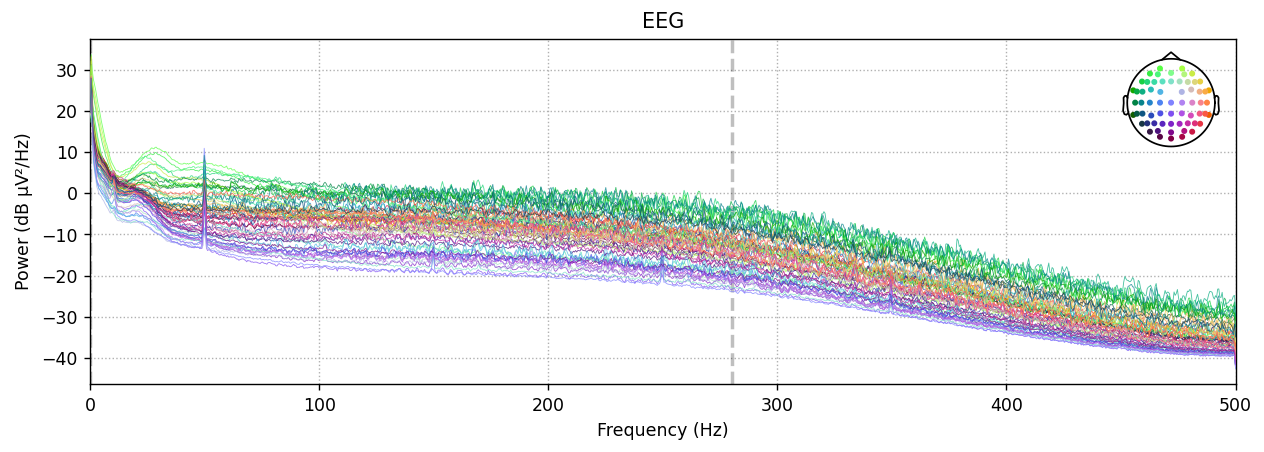

In [5]:
raw.compute_psd().plot(picks="data", amplitude=False)

In [6]:
raw.resample(sfreq=250)
raw.info

Measurement date,"June 02, 2024 13:12:19 GMT"
Experimenter,Unknown
Participant,Unknown
Digitized points,66 points
Good channels,63 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,250.00 Hz
Highpass,0.00 Hz
Lowpass,125.00 Hz


Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


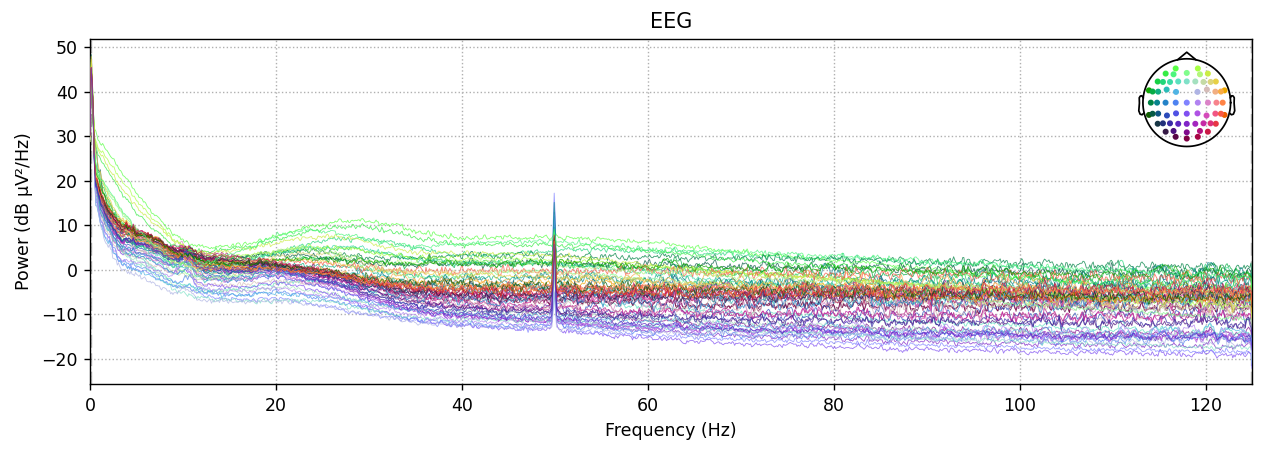

In [7]:
raw.compute_psd().plot(picks="data", amplitude=False)

### Filtering 

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1651 samples (6.604 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


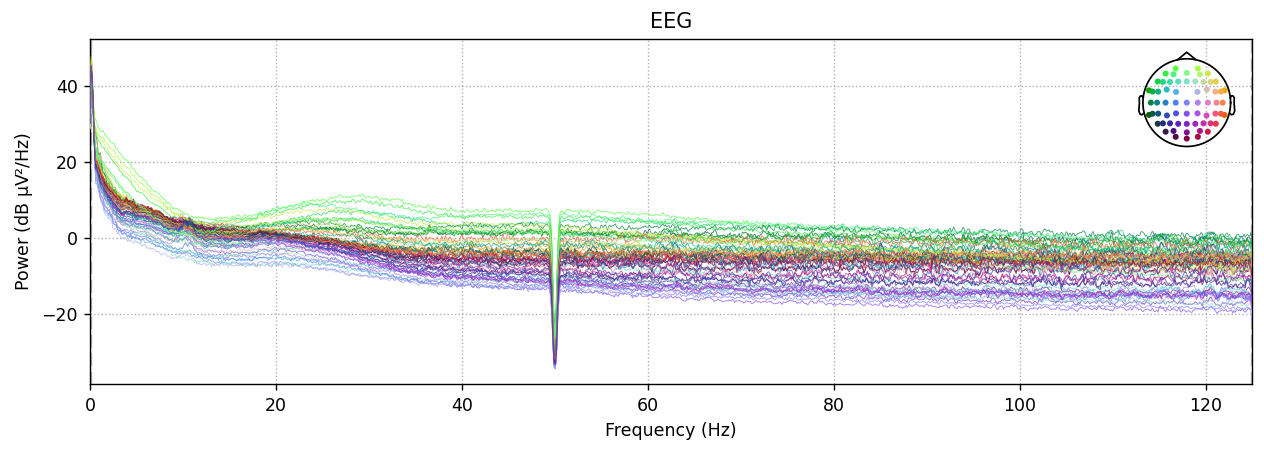

In [8]:
raw.notch_filter(50)
raw.compute_psd().plot(picks="data", amplitude=False)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 8251 samples (33.004 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


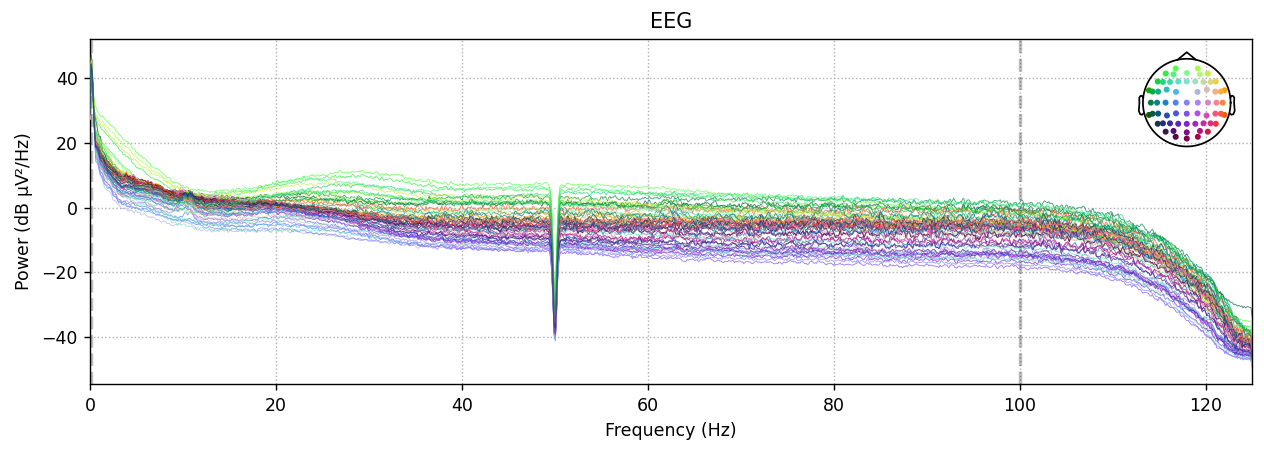

In [9]:
raw.filter(l_freq=0.1,h_freq=100)
raw.compute_psd().plot(picks="data", amplitude=False)

### Epoching 

In [21]:
#Get the events and its marker
events,event_dict = mne.events_from_annotations(raw)
print(event_dict)

Used Annotations descriptions: ['New Segment/', 'Stimulus/S 11', 'Stimulus/S 12', 'Stimulus/S 13', 'Stimulus/S 14', 'Stimulus/S 15', 'Stimulus/S 18', 'Stimulus/S 21', 'Stimulus/S 24', 'Stimulus/S 25', 'Stimulus/S 26']
{'New Segment/': 99999, 'Stimulus/S 11': 11, 'Stimulus/S 12': 12, 'Stimulus/S 13': 13, 'Stimulus/S 14': 14, 'Stimulus/S 15': 15, 'Stimulus/S 18': 18, 'Stimulus/S 21': 21, 'Stimulus/S 24': 24, 'Stimulus/S 25': 25, 'Stimulus/S 26': 26}


In [22]:
epochs = mne.Epochs(raw, events, event_id=[14,15,24,25], tmin=-0.3, tmax=0.7, preload=True)
#fig = epochs.plot(events=events)

Not setting metadata
1800 matching events found
Setting baseline interval to [-0.3, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1800 events and 251 original time points ...
0 bad epochs dropped


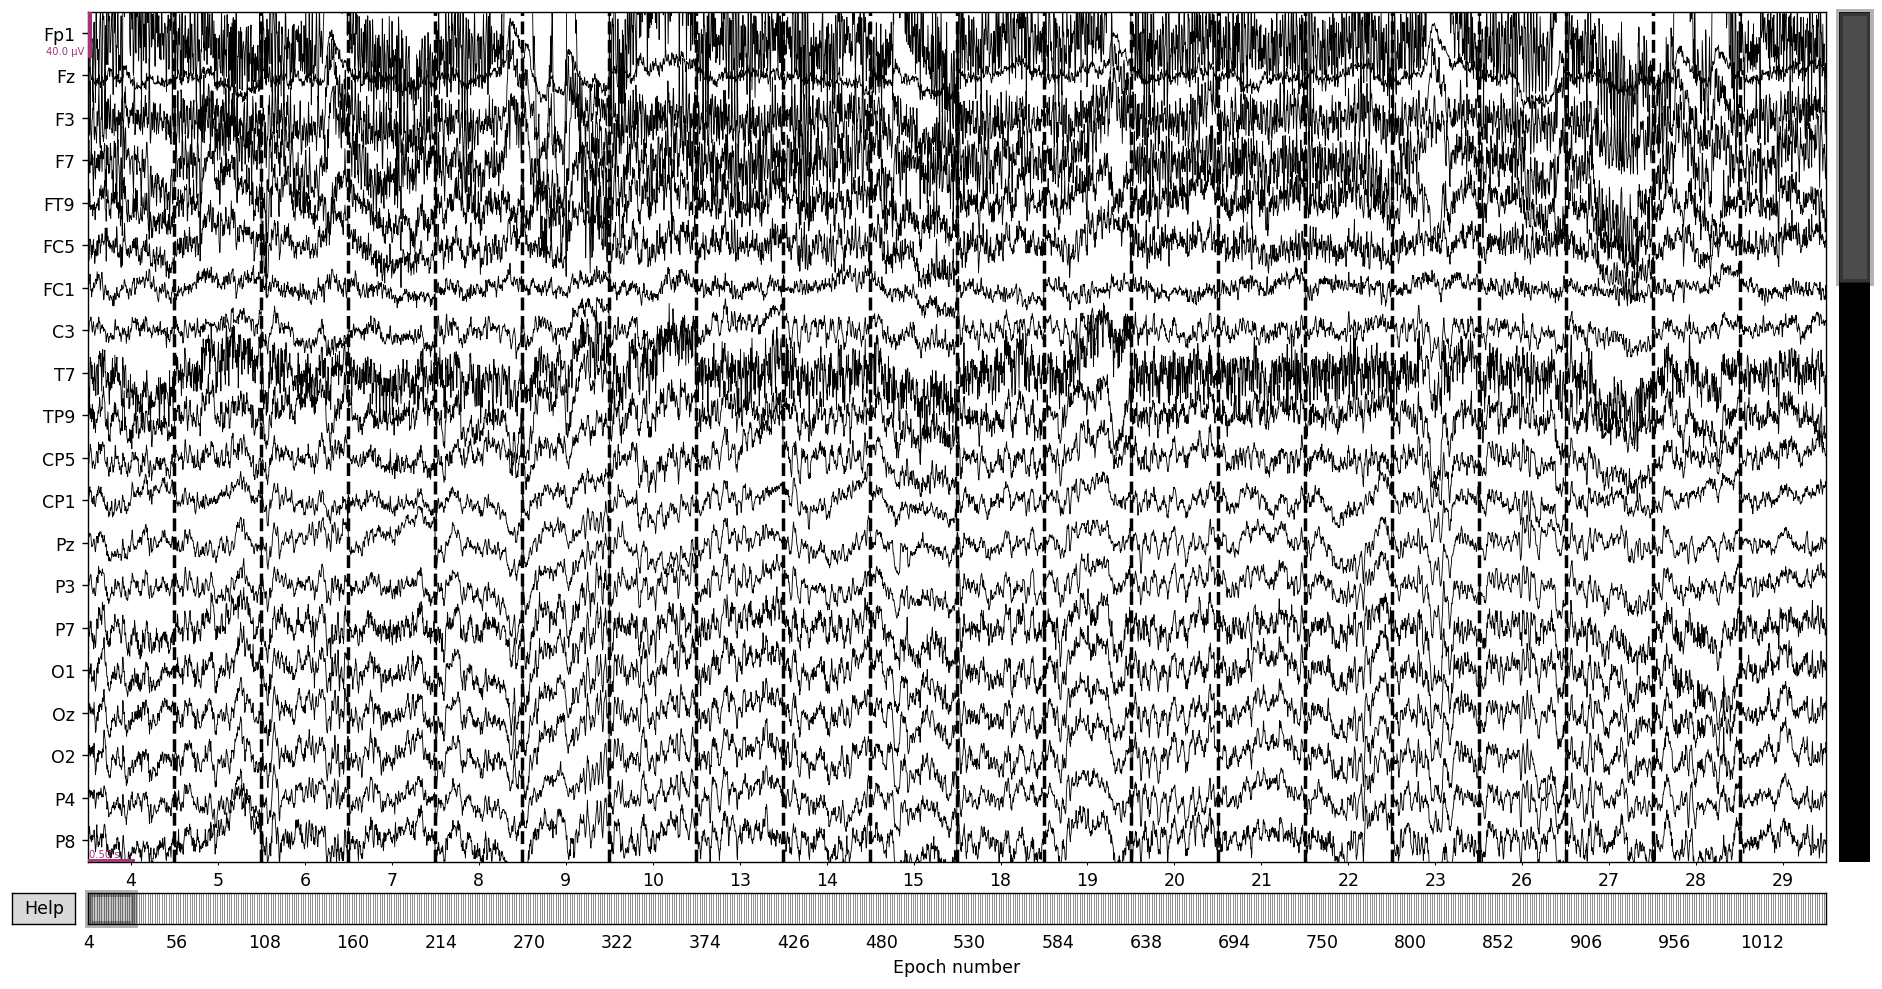

In [12]:
epochs['14'].plot()

In [23]:
print("Total Numner of event in Block 1 :" ,len(epochs['14']),len(epochs['15']))
print("Total Numner of event in Block 2 :" ,len(epochs['24']),len(epochs['25']))

Total Numner of event in Block 1 : 750 150
Total Numner of event in Block 2 : 750 150


### remove eeg epochs with thresold 

In [14]:

# Define the rejection criteria
"""reject_criteria = dict(eeg=70e-6)  # 70 microvolts
reject_criteria  = dict(
    eeg=lambda x: (
        (np.percentile(np.abs(x), 99, axis=1) > 70e-6  ).any(),
        "signal > 70 microV somewhere",
    )
)

# Drop bad epochs based on the rejection criteria
epochs.drop_bad(reject=reject_criteria)"""

1243 bad epochs dropped


Number of events,557
Events,14: 24715: 5624: 21725: 37
Time range,-0.300 – 0.700 s
Baseline,-0.300 – 0.000 s


In [24]:
# Define the rejection criteria
reject_criteria = dict(eeg=70e-6)  # 70 microvolts

# Custom rejection logic
bad_epochs = []
for i, epoch in enumerate(epochs):
    # Find channels that exceed the threshold
    #print((abs(epoch) > reject_criteria['eeg']).any(axis=1).sum())
    bad_channels = (abs(epoch) > reject_criteria['eeg']).any(axis=1) 

    # Check if more than 3 electrodes exceed the threshold
   
    if bad_channels.sum() > 5:
        bad_epochs.append(i)

# Drop the bad epochs
epochs.drop(bad_epochs)


Dropped 797 epochs: 0, 1, 2, 4, 5, 6, 10, 13, 17, 19, 20, 21, 25, 27, 31, 35, 36, 38, 39, 40, 41, 43, 50, 51, 55, 57, 58, 59, 62, 65, 66, 67, 68, 69, 70, 71, 72, 75, 76, 77, 81, 83, 86, 87, 89, 94, 98, 103, 104, 107, 109, 111, 112, 115, 122, 127, 135, 137, 139, 140, 141, 142, 145, 149, 153, 156, 157, 163, 165, 166, 167, 168, 171, 172, 175, 176, 178, 179, 181, 183, 189, 191, 193, 195, 196, 199, 201, 203, 207, 208, 216, 218, 222, 223, 224, 228, 229, 235, 237, 238, 239, 242, 243, 247, 249, 251, 252, 254, 256, 257, 259, 261, 262, 263, 264, 265, 268, 270, 274, 276, 280, 282, 283, 284, 285, 287, 288, 289, 291, 297, 298, 300, 303, 305, 306, 307, 309, 310, 312, 314, 316, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 332, 335, 337, 340, 341, 342, 343, 350, 352, 358, 359, 360, 361, 362, 363, 364, 365, 366, 368, 369, 370, 371, 373, 374, 375, 376, 377, 378, 379, 380, 381, 383, 385, 386, 387, 388, 395, 398, 402, 408, 410, 412, 413, 416, 417, 420, 421, 424, 425, 426, 427, 428, 429, 431, 432, 435

Number of events,1003
Events,14: 41115: 9024: 43225: 70
Time range,-0.300 – 0.700 s
Baseline,-0.300 – 0.000 s


In [25]:
print("Total Numner of event in Block 1 :" ,len(epochs['14']),len(epochs['15']))
print("Total Numner of event in Block 2 :" ,len(epochs['24']),len(epochs['25']))

Total Numner of event in Block 1 : 411 90
Total Numner of event in Block 2 : 432 70


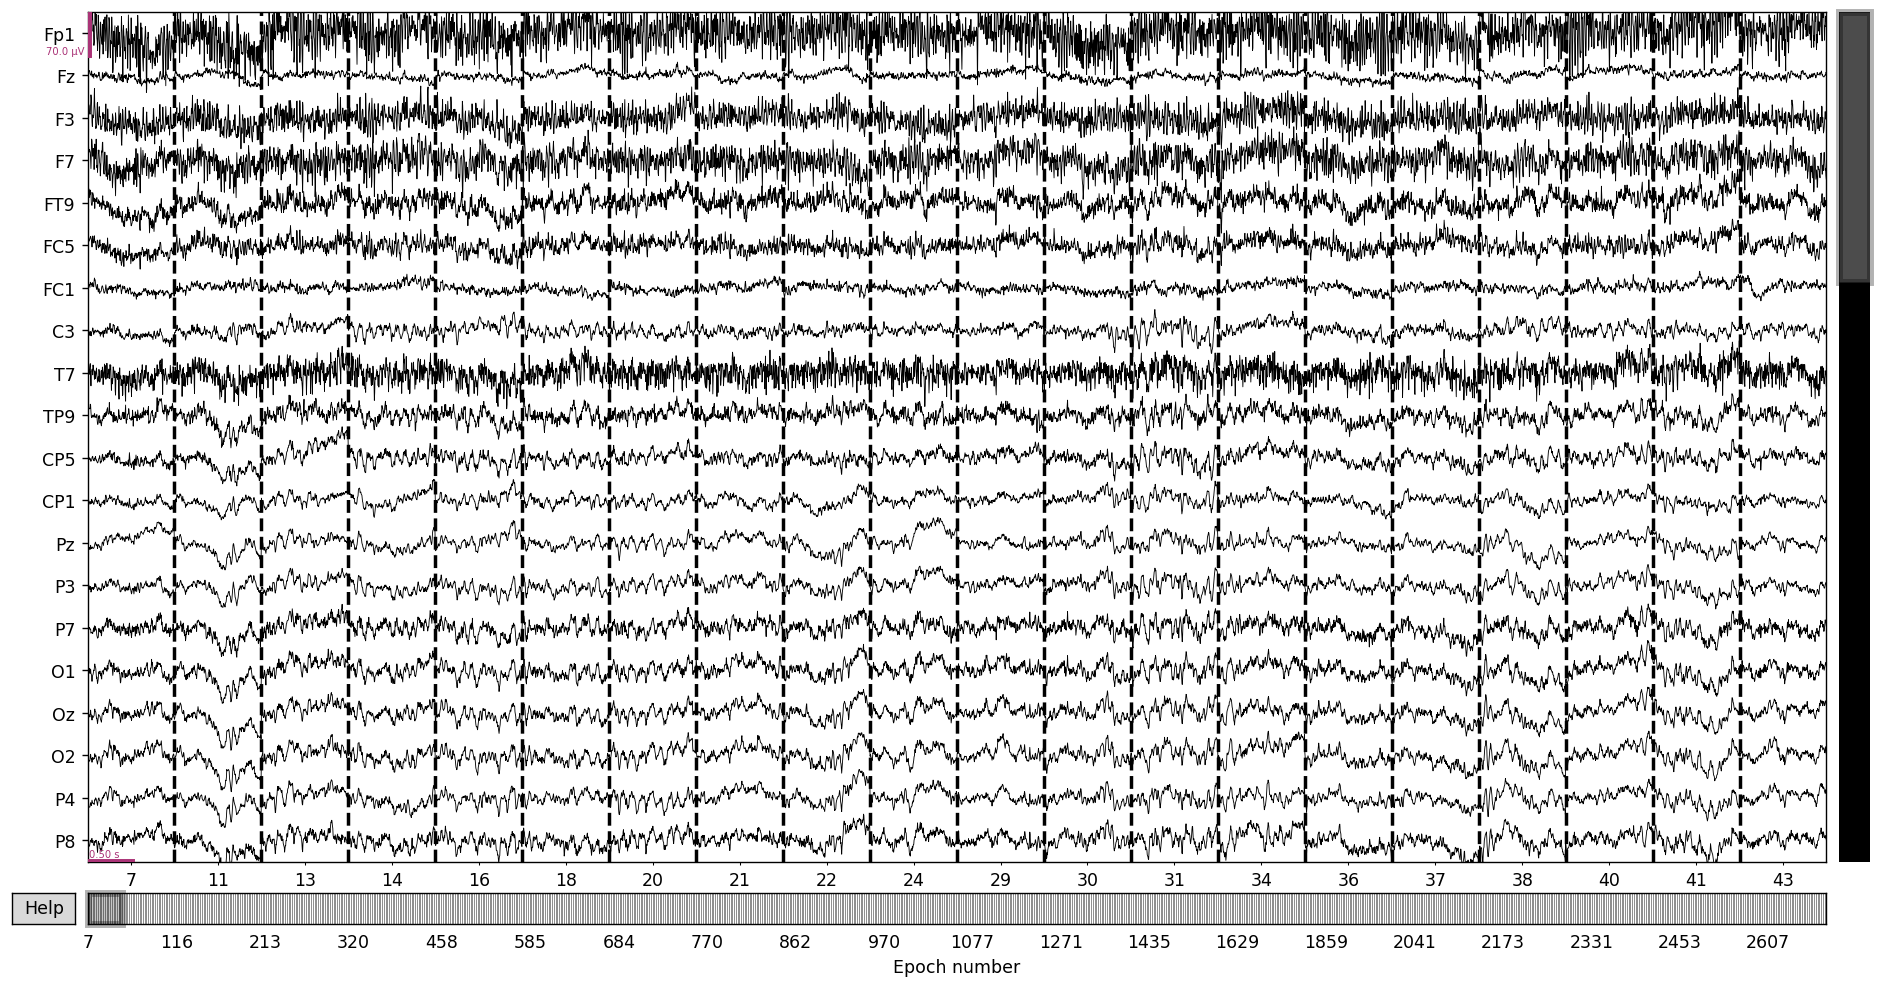

Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


In [26]:
epochs.plot(scalings=dict(eeg=35e-6))

In [27]:

baseline_tmin, baseline_tmax = -.3, 0  # None takes the first timepoint

baseline = (baseline_tmin, baseline_tmax)
B1_devi_eps = epochs['15'].average().apply_baseline(baseline)
B1_sta_eps =  epochs["14"].average().apply_baseline(baseline)

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


In [28]:
# Campare the two contidition of deviant vs standard tone  
evokeds = dict(deviant=B1_devi_eps, standard=B1_sta_eps)
picks = [1,34,35,3,37,36]
mne.viz.plot_compare_evokeds(evokeds, picks=picks, combine="mean")

combining channels using "mean"
combining channels using "mean"


[<Figure size 1000x750 with 1 Axes>]

In [29]:
MMN_erp = mne.combine_evoked([ B1_devi_eps,B1_sta_eps], weights=[-1, 1])
# Campare the two contidition of deviant vs standard tone  
evokeds = dict(deviant=B1_devi_eps, standard=B1_sta_eps,MMN = MMN_erp)
mne.viz.plot_compare_evokeds(evokeds, picks=picks, combine="mean")

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


[<Figure size 1000x750 with 1 Axes>]